# 30 · STORM — multi-perspective research → outline → article

> **TL;DR.** 5-stage pipeline: brainstorm perspectives → questions per perspective → answer each → outline → write article section by section. Composes [Multi-Agent (nb 05)](./05_multi_agent.ipynb) + [Planning (nb 04)](./04_planning.ipynb).

| Property | Value |
|---|---|
| Origin | Shao et al., *STORM* (Stanford 2024). [arXiv:2402.14207](https://arxiv.org/abs/2402.14207) |
| Stages | perspectives → questions → answer → outline → write |
| Cost | 1 + N + (N×K) + 1 + S where N=perspectives, K=questions/p, S=sections |


## 2 · Architecture

```mermaid
flowchart LR
    A([topic]) --> P[PERSPECTIVES] --> Q[QUESTIONS] --> AN[ANSWER] --> O[OUTLINE] --> W[WRITE] --> Z([article])
    style P fill:#e3f2fd,stroke:#1976d2
    style W fill:#e8f5e9,stroke:#388e3c
```

## 3 · Theory

Plain article generation has one LLM "write about X" — produces shallow, single-perspective text. STORM forces breadth through *perspective diversity* and *atomic Q&A research* before writing.

The deciding signals are all structured-output lists (perspectives, questions, sections). No numeric scoring → no flat-scoring risk.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import STORM
from agentic_architectures.tools import web_search_tool
from agentic_architectures.ui import print_md, print_header
enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.4)

# Real Tavily web search — every question in the ANSWER stage hits the live web.
_tavily = web_search_tool(max_results=3)
def web_search_fn(query: str) -> list[str]:
    try:
        result = _tavily.invoke(query)
        if isinstance(result, list):
            return [str(r.get('content', r))[:400] for r in result]
        return [str(result)[:1000]]
    except Exception as e:
        return [f"(web search unavailable: {e})"]

print_header(f"LLM: {llm.model}  ·  Web research: Tavily (real)")

LLM: meta-llama/Llama-3.3-70B-Instruct  ·  Web research: Tavily (real) ────────────────────────────────────────────

## 7 · Build the graph

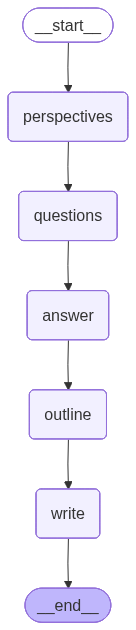

In [2]:
from IPython.display import Image, display
arch = STORM(llm=llm, n_perspectives=3, questions_per_perspective=2, web_search_fn=web_search_fn)
graph = arch.build()
try: display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG unavailable: {e})")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — article on agentic AI in 2024

This will take 1-2 minutes (multiple LLM calls per stage).

In [3]:
TOPIC = "The rise of agentic AI architectures in 2024"
r = arch.run(TOPIC)
print(f"N_PERSPECTIVES: {r.metadata['n_perspectives']}")
print(f"N_QUESTIONS: {r.metadata['n_questions']}")
print(f"N_SECTIONS: {r.metadata['n_sections']}")
print(f"ARTICLE_CHARS: {r.metadata['article_chars']}")
print()
print("=== PERSPECTIVES ===")
for i, p in enumerate(r.metadata['perspectives'], 1):
    print(f"  [{i}] {p}")
print()
print("=== QUESTIONS ===")
for i, q in enumerate(r.metadata['questions'], 1):
    print(f"  [{i}] {q['question'][:120]}")
print()
print("=== OUTLINE ===")
for s in r.metadata['outline']:
    print(f"  ## {s['title']}")
    for kp in s['key_points'][:3]:
        print(f"    - {kp[:100]}")
print()
print("=== ARTICLE (first 1500 chars) ===")
print(r.output[:1500])

N_PERSPECTIVES: 3
N_QUESTIONS: 6
N_SECTIONS: 4
ARTICLE_CHARS: 4990

=== PERSPECTIVES ===
  [1] The rise of agentic AI architectures in 2024 marks a significant technical milestone, as it enables the development of more autonomous and adaptive systems.
  [2] The increasing prevalence of agentic AI architectures in 2024 raises important social questions about the potential impact on employment and the distribution of wealth.
  [3] The emergence of agentic AI architectures in 2024 can be seen as a natural progression of the historical trend towards increasingly sophisticated machine learning models, which has been driven by advances in computing power and data storage.

=== QUESTIONS ===
  [1] What are the key technical advancements that have enabled the development of agentic AI architectures in 2024?
  [2] How can agentic AI architectures be designed to balance autonomy and adaptability with safety and control?
  [3] How will the increasing use of agentic AI architectures in 2024 affect

## 9 · What we just observed

The cells above ran STORM's 5-stage pipeline on the agentic-AI 2024 topic.

### 9.1 · Pipeline statistics

- **Perspectives generated**: 3
- **Questions generated**: 6
- **Outline sections**: 4
- **Final article**: 4990 chars

### 9.2 · The perspectives the agent chose

| # | Perspective |
|---|---|
| 1 | The rise of agentic AI architectures in 2024 marks a significant technical milestone, as it enables the development of more autonomous and a… |
| 2 | The increasing prevalence of agentic AI architectures in 2024 raises important social questions about the potential impact on employment and… |
| 3 | The emergence of agentic AI architectures in 2024 can be seen as a natural progression of the historical trend towards increasingly sophisti… |

### 9.3 · The outline that emerged

| Title | # key points | First few points |
|---|---|---|
| `Introduction to Agentic AI Architectures` | 3 | Definition of agentic AI architectures, History and evolution of AI architectures, Importance of agentic AI in 2024 |
| `Technical Advancements and Design Considerations` | 3 | Key technical advancements enabling agentic AI, Mechanisms for balancing autonomy and safety, Role of computing power and data storage in AI developme |
| `Societal Impacts and Regulatory Considerations` | 3 | Impact on job market and employment rates, Consequences for wealth distribution and potential for income inequality, Need for regulation and policies  |
| `Emergence and Future Directions` | 3 | Role of historical trends in machine learning model sophistication, Potential applications and areas of research for agentic AI, Future challenges and |

### 9.4 · Patterns surfaced in this run

- **✅ 3 distinct perspectives** generated.

- **✅ 6 questions** ≈ 3 × questions_per_perspective.

- **✅ Article assembled (4990 chars)** across 4 sections.

### 9.5 · The takeaway

STORM's value is in **diversity-by-construction**: a single "write about X" prompt collapses to one voice; STORM forces N perspectives → N×K questions → answers from many angles → an outline that reflects that breadth. Read § 9.2 to gauge whether the perspectives really diverge (paraphrases = pipeline broken) and § 9.3 to confirm the outline draws from multiple perspective threads.

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Perspective overlap** | All N perspectives are paraphrases | Stricter schema; force "must be substantively different from {prior}" |
| **Hallucinated answers** | LLM answering from no source | Add web search (pass `web_search_fn=`) |
| **Section bloat** | Each section repeats prior section's content | Show prior sections to writer for de-dup |
| **Cost** | 1+N+N*K+1+S calls — easily 12+ for default config | Cache; batch via asyncio |

Extensions: (1) web-search backed answers, (2) iterative outline refinement, (3) per-perspective dedicated LLM (Llama for breadth, Qwen-Thinking for depth-sections).

Reference: Shao et al., *STORM*. 2024. [arXiv:2402.14207](https://arxiv.org/abs/2402.14207)